Coefficients (slope on size_sqm):
Model           Intercept   Slope (size)
----------------------------------------
  Q10              450.8           1.07
  Q25              218.5          20.70
  Q50              570.8          36.74
  Q75              534.0          57.26
  Q90              196.7          83.17
  OLS               615.3          38.55


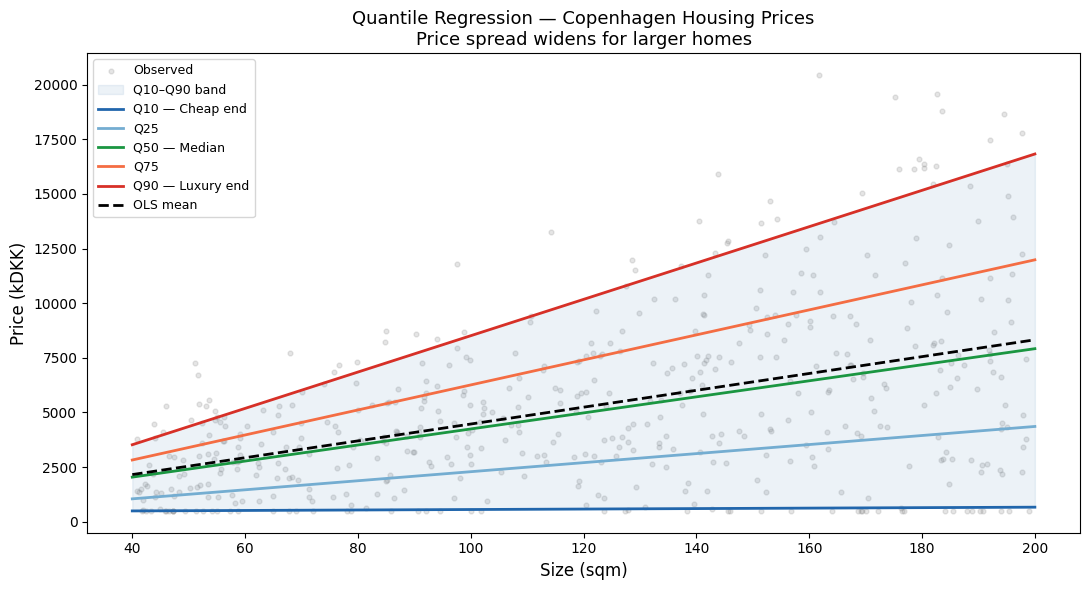


Pinball loss — QR vs OLS:
  Q10: QR=472.95  OLS=1358.45  improvement=+65.2%
  Q25: QR=997.68  OLS=1358.45  improvement=+26.6%
  Q50: QR=1353.74  OLS=1358.45  improvement=+0.3%
  Q75: QR=1131.65  OLS=1358.45  improvement=+16.7%
  Q90: QR=629.19  OLS=1358.45  improvement=+53.7%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

np.random.seed(42)

# ── Data: house prices vs size ──────────────────────────────────────────────
# Variance of price grows with size (cheaper small homes are predictable;
# luxury large homes are wildly spread). Classic heteroskedasticity.
n = 500
size_sqm = np.random.uniform(40, 200, n)
noise     = np.random.normal(0, 500 + 25 * size_sqm, n)   # spread grows with size
price_kDKK = 800 + 35 * size_sqm + noise
price_kDKK = np.clip(price_kDKK, 500, None)

df = pd.DataFrame({'price': price_kDKK, 'size': size_sqm})

# ── Quantile regression at 5 quantiles + OLS ────────────────────────────────
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
qr = {q: smf.quantreg('price ~ size', df).fit(q=q) for q in quantiles}
ols = smf.ols('price ~ size', df).fit()

print("Coefficients (slope on size_sqm):")
print(f"{'Model':<12} {'Intercept':>12} {'Slope (size)':>14}")
print("-" * 40)
for q in quantiles:
    print(f"  Q{int(q*100):<8} {qr[q].params['Intercept']:>12.1f} {qr[q].params['size']:>14.2f}")
print(f"  {'OLS':<10} {ols.params['Intercept']:>12.1f} {ols.params['size']:>14.2f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
x_range = np.linspace(40, 200, 300)
pred_df  = pd.DataFrame({'size': x_range})

palette = {0.10: '#2166ac', 0.25: '#74add1', 0.50: '#1a9641',
           0.75: '#f46d43', 0.90: '#d73027'}
labels  = {0.10: 'Q10 — Cheap end', 0.25: 'Q25', 0.50: 'Q50 — Median',
           0.75: 'Q75', 0.90: 'Q90 — Luxury end'}

fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(df['size'], df['price'], alpha=0.2, s=12, color='gray', label='Observed')
ax.fill_between(x_range,
                qr[0.10].predict(pred_df),
                qr[0.90].predict(pred_df),
                alpha=0.10, color='steelblue', label='Q10–Q90 band')

for q in quantiles:
    ax.plot(x_range, qr[q].predict(pred_df), color=palette[q], lw=2, label=labels[q])

ax.plot(x_range, ols.predict(pred_df), color='black', lw=2,
        linestyle='--', label='OLS mean')

ax.set_xlabel('Size (sqm)', fontsize=12)
ax.set_ylabel('Price (kDKK)', fontsize=12)
ax.set_title('Quantile Regression — Copenhagen Housing Prices\n'
             'Price spread widens for larger homes', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Pinball loss ─────────────────────────────────────────────────────────────
def pinball(y, yhat, tau):
    e = np.array(y) - np.array(yhat)
    return np.mean(np.where(e >= 0, tau * e, (tau - 1) * e))

print("\nPinball loss — QR vs OLS:")
for q in quantiles:
    ql = pinball(df['price'], qr[q].predict(df), q)
    ol = pinball(df['price'], ols.predict(df), q)
    print(f"  Q{int(q*100)}: QR={ql:.2f}  OLS={ol:.2f}  improvement={((ol-ql)/ol*100):+.1f}%")

### The use case is Copenhagen housing prices

— apartment price (kDKK) as a function of size (sqm). The noise grows with size, so small apartments are predictably priced but large/luxury ones are widely spread. OLS gives one regression line through the middle. The five quantile lines show that the slope is steeper at Q90 than Q10 — meaning an extra sqm adds more value at the luxury end of the market than at the budget end, something OLS completely masks.